In [15]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from turbos.sim.p3d.p3d_1 import p3d


vars = [
    "ne", "jex", "jey", "jez",
    "pexx", "pexy", "pexz", "peyy", "peyz", "pezz",
    "ni", "jix", "jiy", "jiz",
    "pixx", "pixy", "pixz", "piyy", "piyz", "pizz",
]

run =p3d('/archive/tulasi/149p6_rs/', filenum='000')
# run =p3d('/archive/tulasi/MEGARUNS_DATA_SUBSET/149p6', filenum = '000')
# print(run.nx, run.ny, run.nz, run.data_type)
raw = run.load_xarray(0, variables= vars)
print(raw['jez'].dims)
# print(raw)
# print(raw.x.values[:5], raw.y.values[:5])
# print(raw.attrs)

('x', 'y')


In [17]:
# import matplotlib.pyplot as plt

# plt.imshow(raw['jez'], cmap = 'bwr', origin='lower', extent=[raw.x.values[0], raw.x.values[-1], raw.y.values[0], raw.y.values[-1]])
# plt.colorbar()
# plt.show()

In [18]:
from turbos.moments.pressure import P_tensor


Pe = P_tensor(
    raw["pexx"],
    raw["pexy"],
    raw["pexz"],
    raw["peyy"],
    raw["peyz"],
    raw["pezz"],
    name="Pe",
)

print(Pe.dims)

('x', 'y', 'i', 'j')


In [19]:
from turbos.vector import vector
sp = 'e'

if sp == 'e':
		uex = -(raw['jex']/raw['ne'])
		uey = -(raw['jey']/raw['ne'])
		uez = -(raw['jez']/raw['ne'])
if sp == 'i':   
		uix = (raw['jix']/raw['ni'])
		uiy = (raw['jiy']/raw['ni'])
		uiz = (raw['jiz']/raw['ni'])

        
ue = vector(
    uex,
    uey,
    uez,
    name="ue",
)

print(ue.dims)

('x', 'y', 'comp')


In [20]:
from turbos.gradients.pderiv import vec_grad

grad_u = vec_grad(ue)


print(grad_u.dims)


('x', 'y', 'i', 'j')


<xarray.DataArray (x: 4096, y: 4096, i: 3, j: 3)> Size: 1GB
array([[[[-2.38299469e-02, -5.82357729e-03, -6.26794901e-03],
         [-5.82357729e-03, -1.56876842e-02,  5.33285970e-03],
         [-6.26794901e-03,  5.33285970e-03,  3.95176311e-02]],

        [[-2.17261910e-02, -2.72411667e-03,  8.55658218e-05],
         [-2.72411667e-03, -1.39556229e-02,  1.46616232e-02],
         [ 8.55658218e-05,  1.46616232e-02,  3.56818140e-02]],

        [[-1.63720846e-02, -2.41709780e-03, -6.43239170e-03],
         [-2.41709780e-03, -1.15181208e-02,  1.26189860e-02],
         [-6.43239170e-03,  1.26189860e-02,  2.78902054e-02]],

        ...,

        [[-1.81465447e-02,  5.77755366e-03, -1.33382408e-02],
         [ 5.77755366e-03, -2.75027752e-02,  9.28097591e-03],
         [-1.33382408e-02,  9.28097591e-03,  4.56493199e-02]],

        [[-1.54828827e-02, -2.05873675e-03, -8.66235048e-03],
         [-2.05873675e-03, -3.23129396e-02,  1.27001209e-02],
...
         [-7.35087553e-03,  1.26528786e-02,  4

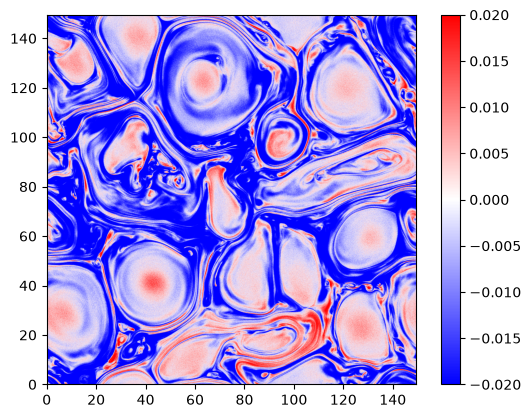

In [21]:
from turbos.moments.pressure import scalar_pressure, dev_P



Pi = dev_P(Pe)

print(Pi)
plt.imshow(Pi.sel(i='y', j='y'), cmap = 'bwr', origin='lower', extent=[raw.x.values[0], raw.x.values[-1], raw.y.values[0], raw.y.values[-1]])
plt.clim(-0.02, 0.02)
plt.colorbar()
plt.show()

('x', 'y', 'i', 'j')


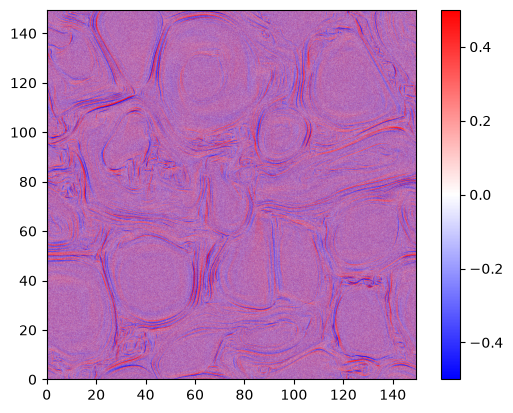

In [22]:
from turbos.gradients.pderiv import strain_tensor

D = strain_tensor(ue)
print(D.dims)

plt.imshow(D.sel(i='x', j='y'), cmap = 'bwr', origin='lower', extent=[raw.x.values[0], raw.x.values[-1], raw.y.values[0], raw.y.values[-1]])
plt.clim(-0.5, 0.5)
plt.colorbar()
plt.show()

In [23]:

from turbos.pressure_strain import pressure_strain

PiDe = pressure_strain(
    Pe,
    ue,
)
print(PiDe['PiD'].dims)

('x', 'y')


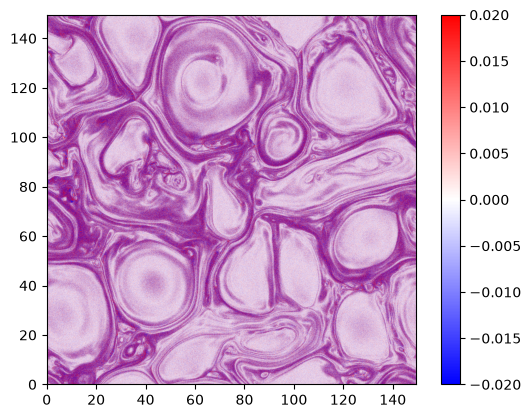

In [24]:
plt.imshow(PiDe['PiD'], cmap = 'bwr', origin='lower', extent=[raw.x.values[0], raw.x.values[-1], raw.y.values[0], raw.y.values[-1]])
plt.clim(-0.02, 0.02)
plt.colorbar()
plt.show()

In [25]:
print(Pe.dims)
print(ue.dims)

('x', 'y', 'i', 'j')
('x', 'y', 'comp')


In [26]:
# for i in range(119):
#     raw = run.load_xarray(i, variables= run.primitives)
#     raw['jez'] = 